In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from IPython.display import Image
import os

os.environ['CUDA_LAUNCH_BLOCKING']='1'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

In [3]:
import torch
import sys
print(torch.__version__)
print(sys.version)
print(sys.executable)
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.device_count())

2.12.0+cu130
3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]
d:\love\Honghan Chen AI\.venv\Scripts\python.exe
True
13.0
1


In [6]:
# 数据路径
train_dir = 'training_set'
val_dir = 'test_set'

提取前5行数据观察

In [4]:
# 数据预处理（包括数据增强）思考一下训练和验证的数据预处理有什么不同？
train_transform = transforms.Compose([
    transforms.Resize(256),  # 将短边调整为256，确保图像可以进行裁剪操作
    transforms.RandomResizedCrop(224),  # 随机裁剪出224x224大小的区域
    transforms.RandomHorizontalFlip(),  # 随机水平翻转
    transforms.RandomRotation(15),  # 随机旋转，最大旋转角度为15度
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # 标准化
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet50要求输入尺寸为224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # ImageNet的均值和标准差
])

## <font color=blue>3 创建数据读取类 </font>

In [7]:
# 加载数据集
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

注意数据加载器中，什么函数调用需要调用 shuffle=True 参数？

## <font color=blue>4 创建CNN模型 </font>

In [8]:
# 加载ResNet50模型，并加载ImageNet预训练权重， 并查看模型结构特别注意最后一层FC输入和输出分别是多少？
import torchvision.models as models
model = models.resnet50(pretrained=True)
print(model)

d:\love\Honghan Chen AI\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\love\Honghan Chen AI\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [9]:
# 修改最后一层FC层（输出2个类别：猫和狗） 结合上面的模型输出下面这句是干上面用的？
model.fc = nn.Linear(model.fc.in_features, 2)

# 使用GPU（如果可用）
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## <font color=blue>5 训练模型 </font>

In [10]:
# 初始化最好的精度和模型
best_acc = 0.0
best_model_wts = model.state_dict()

#课上时间短,同学们可以尝试增加训练的epochs，达到更好的效果
epochs=3

# 训练模型
for epoch in range(epochs):
    model.train()  # 切换到训练模式
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # 零梯度
        optimizer.zero_grad()

        # 前向传播
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # 反向传播
        loss.backward()
        optimizer.step()

        # 计算损失和精度
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')

    # 每个epoch后验证模型
    model.eval()  # 切换到评估模式
    with torch.no_grad():
        val_correct = 0
        val_total = 0
        for val_inputs, val_labels in val_loader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)

            val_outputs = model(val_inputs)
            _, val_predicted = torch.max(val_outputs, 1)
            val_total += val_labels.size(0)
            val_correct += (val_predicted == val_labels).sum().item()

        val_acc = 100 * val_correct / val_total
        print(f'Validation Accuracy: {val_acc:.2f}%')

        # 如果当前验证精度更好，保存模型
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = model.state_dict()
            print(f"New best model with validation accuracy: {best_acc:.2f}%")

# 加载最佳模型权重
model.load_state_dict(best_model_wts)

# 保存最佳模型
torch.save(model.state_dict(), 'best_resnet50_cat_dog.pth')
print('Best model saved as best_resnet50_cat_dog.pth')

Epoch [1/3], Loss: 0.6554, Accuracy: 62.01%
Validation Accuracy: 67.77%
New best model with validation accuracy: 67.77%
Epoch [2/3], Loss: 0.5771, Accuracy: 70.16%
Validation Accuracy: 69.95%
New best model with validation accuracy: 69.95%
Epoch [3/3], Loss: 0.5318, Accuracy: 73.47%
Validation Accuracy: 70.00%
New best model with validation accuracy: 70.00%
Best model saved as best_resnet50_cat_dog.pth


## <font color=blue>6 随机读取一张测试图片，进行测试 </font>

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1589178..2.4831376].


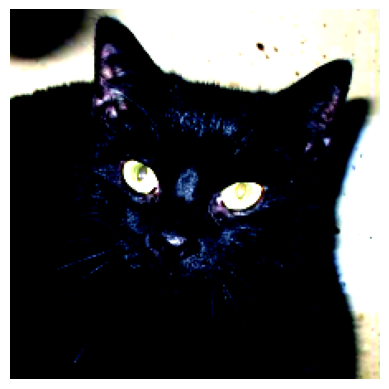

Predicted class: cats


In [15]:
import random
import matplotlib.pyplot as plt
# 重新创建模型结构
model = models.resnet50(pretrained=False)  # 使用未初始化的模型结构
model.fc = torch.nn.Linear(model.fc.in_features, 2)  # 修改最后一层

# 加载模型的权重
model.load_state_dict(torch.load('best_resnet50_cat_dog.pth'))

#模型放入GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)  # 将模型转移到GPU或CPU

# 切换到评估模式
model.eval()

# 随机选择一张图片
image_idx = random.randint(0, len(val_dataset) - 1)  # 随机选择一个索引
image, label = val_dataset[image_idx]

# 显示图像
plt.imshow(image.permute(1, 2, 0))  # 将tensor维度转换为(H, W, C)
plt.axis('off')  # 关闭坐标轴
plt.show()

# 扩展图像的批次维度并输入到模型中
image = image.unsqueeze(0)  # 将图像从 [C, H, W] 转换为 [1, C, H, W]
image = image.to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))  # 如果有GPU可用，使用GPU

# 获取模型输出
with torch.no_grad():  # 在推理时禁用梯度计算
    output = model(image)

# 输出分类结果
_, predicted = torch.max(output, 1)  # 获取预测类别
class_names = val_dataset.classes  # 获取类别名称（猫/狗）
predicted_class = class_names[predicted.item()]  # 获取预测的类别名称

print(f"Predicted class: {predicted_class}")